In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
experiment_df = pd.read_csv('/home/na658/multi-task2/experiment_results/experiment_results.csv')

In [12]:
experiment_df.overlap

0      0
1      0
2      0
3      0
4      0
5      0
6     40
7     40
8     40
9     40
10    40
11    40
Name: overlap, dtype: int64

In [8]:
experiment_df.head()

,timestamp,active_dim_1,active_dim_2,c,epochs,final_epoch,final_train_loss,final_val_loss,init_method,inp_dim,...,no_tuning,one_task,overlap,plot_ground_truth_only,save_path,save_weights,scaling,seed,threshold,w_scaling
0,2025-10-10 13:21:11,40,40,0.00001,100000,377,9.576739e-11,1.690014,simple,1000,...,False,True,0,False,data/diagonal/sparse_overlap/seed=0--active_di...,True,0.001,0,1.000000e-10,1.0
1,2025-10-10 13:21:25,40,40,0.00001,100000,2043,9.938223e-11,2.584529,simple,1000,...,False,True,0,False,data/diagonal/sparse_overlap/seed=0--active_di...,True,0.001,0,1.000000e-10,1.0
2,2025-10-10 13:21:45,40,40,0.00001,100000,2315,9.982347e-11,1.670757,simple,1000,...,False,True,0,False,data/diagonal/sparse_overlap/seed=0--active_di...,True,0.001,0,1.000000e-10,1.0
3,2025-10-10 13:22:04,40,40,0.00001,100000,8984,9.975462e-11,0.973847,simple,1000,...,False,True,0,False,data/diagonal/sparse_overlap/seed=0--active_di...,True,0.001,0,1.000000e-10,1.0
4,2025-10-10 13:22:54,40,40,0.00001,100000,54108,9.997726e-11,0.035046,simple,1000,...,False,True,0,False,data/diagonal/sparse_overlap/seed=0--active_di...,True,0.001,0,1.000000e-10,1.0


In [6]:
experiment_df.columns

Index(['timestamp', 'active_dim_1', 'active_dim_2', 'c', 'epochs',
       'final_epoch', 'final_train_loss', 'final_val_loss', 'init_method',
       'inp_dim', 'linear_readout', 'lmda', 'load_model', 'lr', 'model_path',
       'model_scaling', 'n_train1', 'n_train2', 'no_tuning', 'one_task',
       'overlap', 'plot_ground_truth_only', 'save_path', 'save_weights',
       'scaling', 'seed', 'threshold', 'w_scaling'],
      dtype='object')

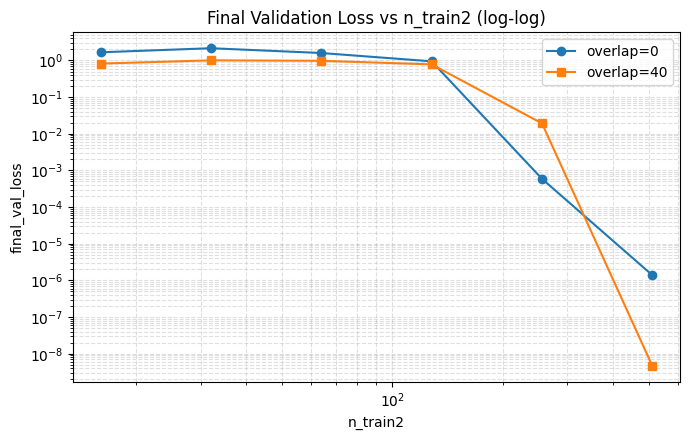

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results
csv_path = "/home/na658/multi-task2/experiment_results_2.csv"
df = pd.read_csv(csv_path)

# Ensure expected columns and numeric types
df["n_train2"] = pd.to_numeric(df["n_train2"], errors="coerce")
df["final_val_loss"] = pd.to_numeric(df["final_val_mse"], errors="coerce")

# If 'overlap' isn't present, try deriving it from 'overlap_bool' and 'active_dim_2'
if "overlap" not in df.columns and {"overlap_bool", "active_dim_2"}.issubset(df.columns):
    df["overlap"] = df["overlap_bool"].map({"no": 0, "yes": None})
    df.loc[df["overlap"].isna(), "overlap"] = pd.to_numeric(df.loc[df["overlap"].isna(), "active_dim_2"], errors="coerce")

# Drop rows missing required fields
df = df.dropna(subset=["n_train2", "final_val_loss", "overlap"])

def prepare_series(dataframe, overlap_value):
    sub = dataframe[dataframe["overlap"] == overlap_value]
    if sub.empty:
        return None
    return (
        sub.groupby("n_train2", as_index=False)["final_val_loss"]
           .median()
           .sort_values("n_train2")
    )

plot0 = prepare_series(df, 0)
plot40 = prepare_series(df, 40)

fig, ax = plt.subplots(figsize=(7, 4.5))
if plot0 is not None:
    ax.plot(plot0["n_train2"], plot0["final_val_loss"], marker="o", linestyle="-", label="overlap=0")
if plot40 is not None:
    ax.plot(plot40["n_train2"], plot40["final_val_loss"], marker="s", linestyle="-", label="overlap=40")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n_train2")
ax.set_ylabel("final_val_loss")
ax.set_title("Final Validation Loss vs n_train2 (log-log)")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
df.head()

,active_dim_1,active_dim_2,epochs,final_train_mse,final_val_mse,inp_dim,linear_readout,lr,model_path,model_scaling,n_train1,n_train2,one_task,overlap,save_path,scaling,seed,threshold
0,40,40,100000,9.454269e-11,6.090632e-01,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,16,True,40,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10
1,40,40,100000,9.454269e-11,6.090632e-01,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,16,True,40,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10
2,40,40,100000,9.968150e-11,3.829901e-01,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,32,True,40,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10
3,40,40,100000,9.995679e-11,2.893378e-05,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,64,True,40,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10
4,40,40,100000,9.959887e-10,1.200637e-07,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,128,True,40,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
df = pd.read_csv('/home/na658/multi-task2/experiment_results.csv')


In [15]:
df.head()

,active_dim_1,active_dim_2,c,epochs,final_train_mse,final_val_mse,init_method,inp_dim,linear_readout,lmda,...,n_train2,one_task,overlap_bool,pretrain_overlap,same_signs,save_path,scaling,seed,threshold,w_scaling
0,40,5.0,0.00001,100000,9.418570e-11,1.568362,complex,1000,False,0.000000,...,16,True,no,NaN,1.0,data/diagonal/sparse_overlap/seed=0--active_di...,NaN,0,1.000000e-10,1.0
1,40,5.0,0.00001,100000,9.418570e-11,1.568362,complex,1000,False,0.000000,...,16,True,no,NaN,1.0,data/diagonal/sparse_overlap/seed=0--active_di...,NaN,0,1.000000e-10,1.0
2,40,5.0,0.00001,100000,9.418570e-11,1.568362,complex,1000,False,0.000000,...,16,True,no,NaN,1.0,data/diagonal/sparse_overlap/seed=0--active_di...,NaN,0,1.000000e-10,1.0
3,40,5.0,0.00001,100000,9.243527e-11,1.574322,complex,1000,False,-0.000010,...,16,True,no,NaN,1.0,data/diagonal/sparse_overlap/seed=0--active_di...,NaN,0,1.000000e-10,1.0
4,40,5.0,0.00001,100000,9.328708e-11,1.573417,complex,1000,False,-0.000008,...,16,True,no,NaN,1.0,data/diagonal/sparse_overlap/seed=0--active_di...,NaN,0,1.000000e-10,1.0


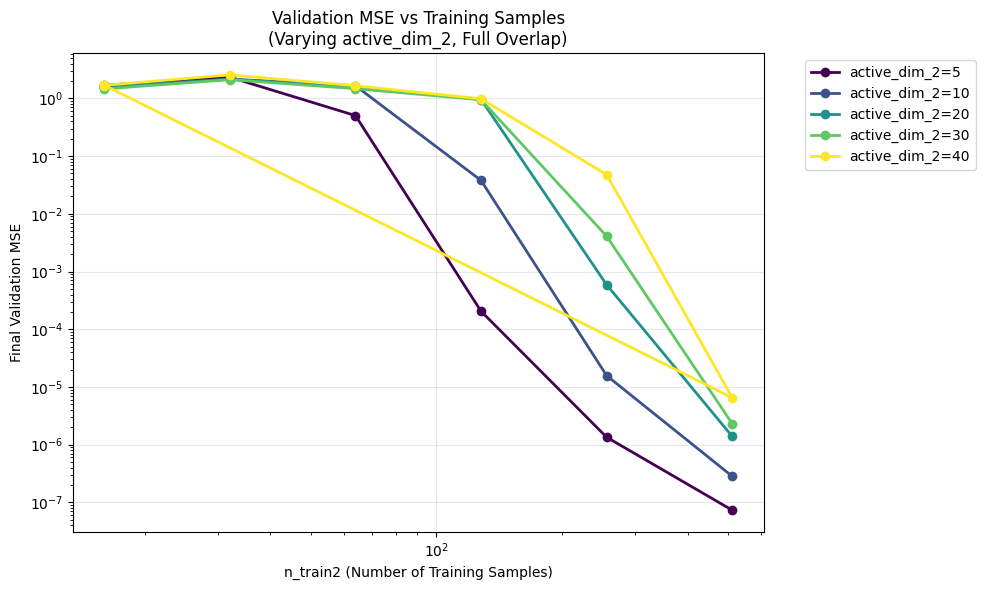

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
df = pd.read_csv('/home/na658/multi-task2/experiment_results_2.csv')

# Filter for the relevant experiments (one_task=True, overlap_bool='yes')
# Since overlap = active_dim_2 when overlap_bool='yes', we can filter by this relationship
df_filtered = df[
    (df['one_task'] == True) & 
    (df['overlap'] == 0)  # This ensures overlap_bool='yes'
].copy()

# Create the plot
plt.figure(figsize=(10, 6))

# Get unique active_dim_2 values and sort them
active_dims = sorted(df_filtered['active_dim_2'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(active_dims)))

# Plot Final Validation MSE vs n_train2 for different active_dim_2
for i, active_dim in enumerate(active_dims):
    subset = df_filtered[df_filtered['active_dim_2'] == active_dim]
    plt.plot(subset['n_train2'], subset['final_val_mse'], 
             'o-', color=colors[i], label=f'active_dim_2={active_dim}', 
             linewidth=2, markersize=6)

plt.xlabel('n_train2 (Number of Training Samples)')
plt.ylabel('Final Validation MSE')
plt.title('Validation MSE vs Training Samples\n(Varying active_dim_2, Full Overlap)')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [4]:
df.columns

Index(['active_dim_1', 'active_dim_2', 'epochs', 'final_train_mse',
       'final_val_mse', 'inp_dim', 'linear_readout', 'lr', 'model_path',
       'model_scaling', 'n_train1', 'n_train2', 'one_task', 'overlap',
       'save_path', 'scaling', 'seed', 'threshold'],
      dtype='object')

In [3]:
df.head()

,active_dim_1,active_dim_2,epochs,final_train_mse,final_val_mse,inp_dim,linear_readout,lr,model_path,model_scaling,n_train1,n_train2,one_task,overlap,save_path,scaling,seed,threshold
0,40,40,100000,9.454269e-11,0.609063,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,16,True,40,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10
1,40,40,100000,9.454269e-11,0.609063,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,16,True,40,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10
2,40,40,100000,9.968150e-11,0.382990,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,32,True,40,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10
3,40,40,100000,9.995679e-11,0.000029,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,64,True,40,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10


In [2]:
df.head()

,active_dim_1,active_dim_2,c,epochs,final_train_mse,final_val_mse,init_method,inp_dim,linear_readout,lmda,...,n_train2,one_task,overlap_bool,pretrain_overlap,same_signs,save_path,scaling,seed,threshold,w_scaling
0,40,5.0,0.00001,100000,9.418570e-11,1.568362,complex,1000,False,0.000000,...,16,True,no,NaN,1.0,data/diagonal/sparse_overlap/seed=0--active_di...,NaN,0,1.000000e-10,1.0
1,40,5.0,0.00001,100000,9.418570e-11,1.568362,complex,1000,False,0.000000,...,16,True,no,NaN,1.0,data/diagonal/sparse_overlap/seed=0--active_di...,NaN,0,1.000000e-10,1.0
2,40,5.0,0.00001,100000,9.418570e-11,1.568362,complex,1000,False,0.000000,...,16,True,no,NaN,1.0,data/diagonal/sparse_overlap/seed=0--active_di...,NaN,0,1.000000e-10,1.0
3,40,5.0,0.00001,100000,9.243527e-11,1.574322,complex,1000,False,-0.000010,...,16,True,no,NaN,1.0,data/diagonal/sparse_overlap/seed=0--active_di...,NaN,0,1.000000e-10,1.0
4,40,5.0,0.00001,100000,9.328708e-11,1.573417,complex,1000,False,-0.000008,...,16,True,no,NaN,1.0,data/diagonal/sparse_overlap/seed=0--active_di...,NaN,0,1.000000e-10,1.0


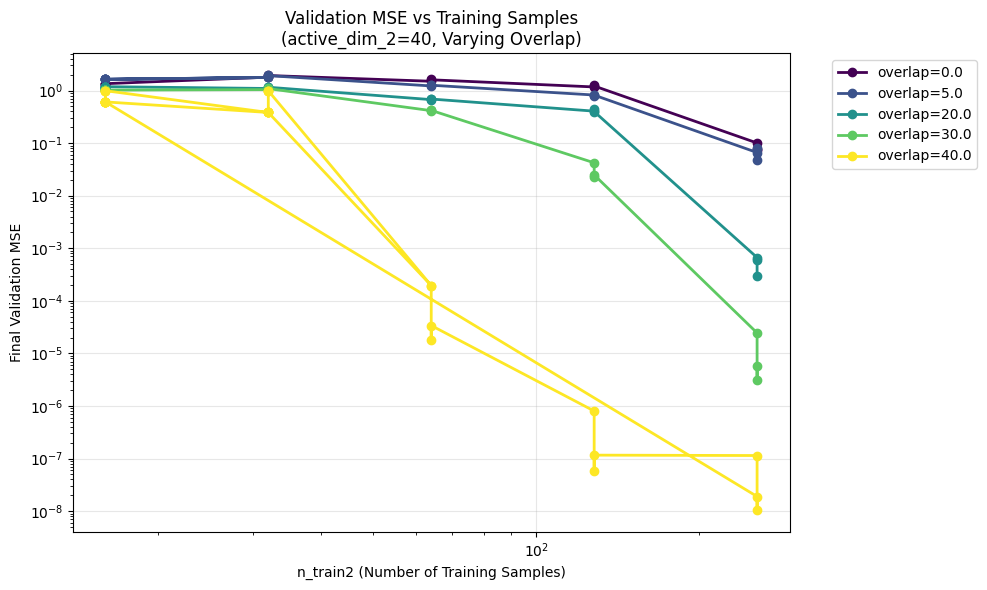

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
df = pd.read_csv('/home/na658/multi-task2/experiment_results.csv')

# Filter for the relevant experiments (one_task=True, active_dim_2=40)
df_filtered = df[
    (df['one_task'] == True) & 
    (df['active_dim_2'] == 40)
].copy()

# Create the plot
plt.figure(figsize=(10, 6))

# Get unique overlap values and sort them
overlap_values = sorted(df_filtered['pretrain_overlap'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(overlap_values)))

# Plot Final Validation MSE vs n_train2 for different overlap values
for i, overlap in enumerate(overlap_values):
    subset = df_filtered[df_filtered['pretrain_overlap'] == overlap]
    plt.plot(subset['n_train2'], subset['final_val_mse'], 
             'o-', color=colors[i], label=f'overlap={overlap}', 
             linewidth=2, markersize=6)

plt.xlabel('n_train2 (Number of Training Samples)')
plt.ylabel('Final Validation MSE')
plt.title('Validation MSE vs Training Samples\n(active_dim_2=40, Varying Overlap)')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

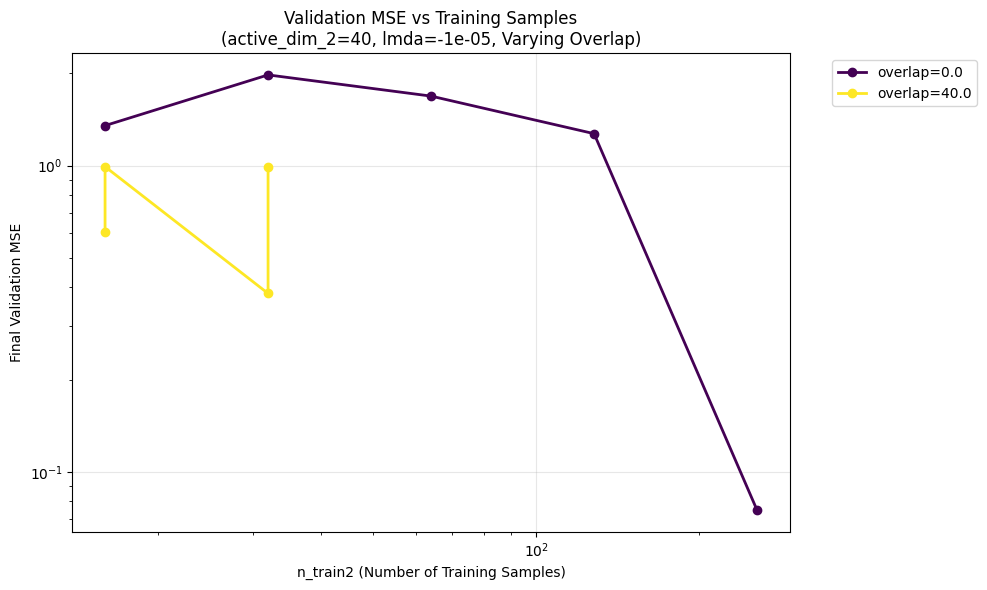

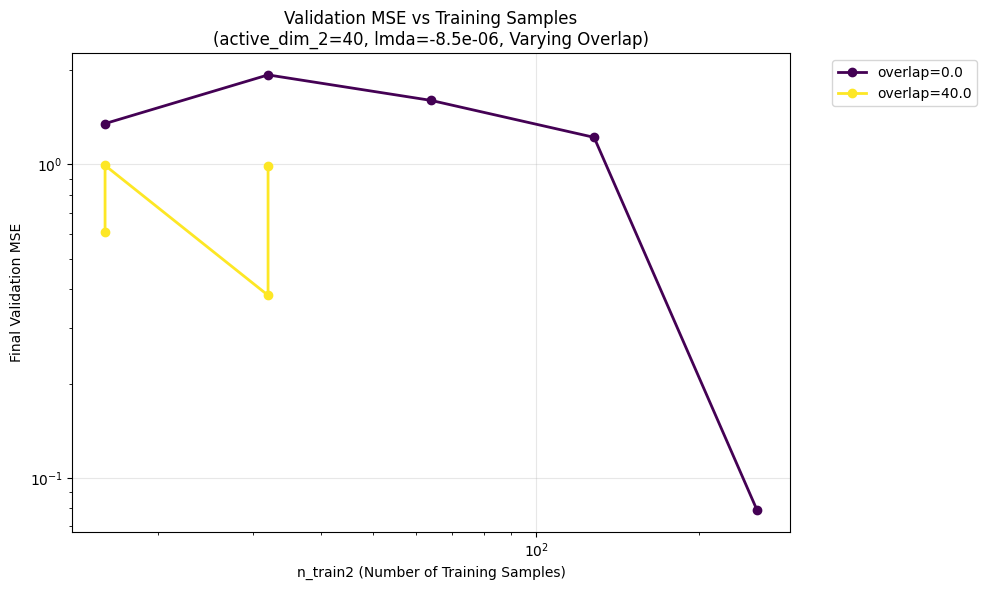

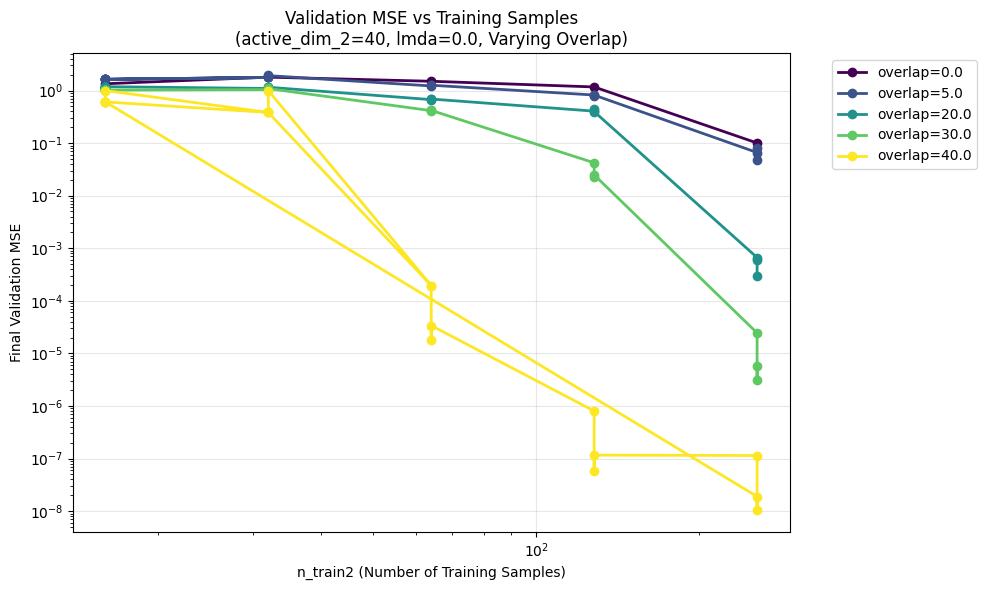

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
df = pd.read_csv('/home/na658/multi-task2/experiment_results.csv')

# Filter for the relevant experiments (one_task=True, active_dim_2=40)
df_filtered = df[
    (df['one_task'] == True) &
    (df['active_dim_2'] == 40)
].copy()

# Get unique lmda values
lmda_values = sorted(df_filtered['lmda'].unique())

# Loop over each lmda and plot a separate figure
for lmda in lmda_values:
    subset_lmda = df_filtered[df_filtered['lmda'] == lmda]
    
    plt.figure(figsize=(10, 6))
    
    overlap_values = sorted(subset_lmda['pretrain_overlap'].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(overlap_values)))
    
    for i, overlap in enumerate(overlap_values):
        subset = subset_lmda[subset_lmda['pretrain_overlap'] == overlap]
        plt.plot(
            subset['n_train2'], subset['final_val_mse'],
            'o-', color=colors[i], label=f'overlap={overlap}',
            linewidth=2, markersize=6
        )
    
    plt.xlabel('n_train2 (Number of Training Samples)')
    plt.ylabel('Final Validation MSE')
    plt.title(f'Validation MSE vs Training Samples\n(active_dim_2=40, lmda={lmda}, Varying Overlap)')
    plt.xscale('log')
    plt.yscale('log')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [6]:
df.lmda.value_counts()

lmda
 0.000000    115
-0.000010     39
-0.000008     39
Name: count, dtype: int64

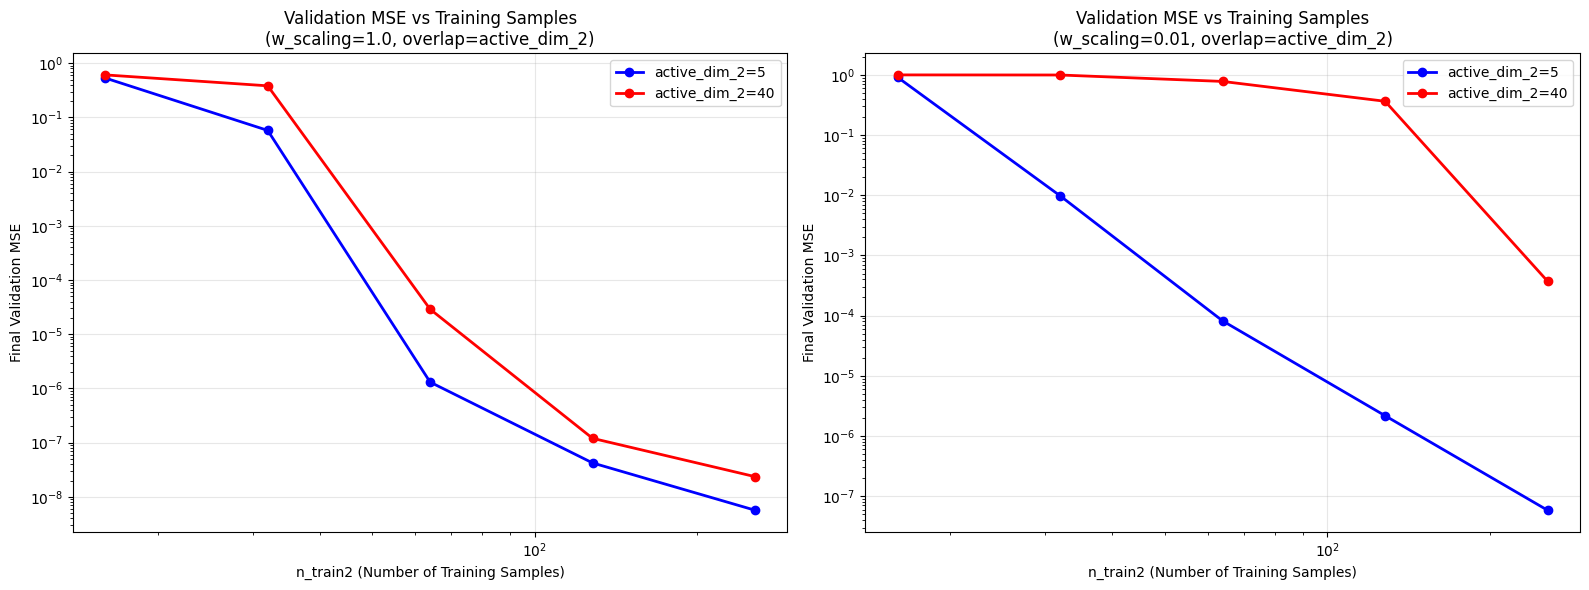

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
df = pd.read_csv('/home/na658/multi-task2/experiment_results.csv')

# Filter for the relevant experiments (one_task=True, overlap=active_dim_2)
df_filtered = df[
    (df['one_task'] == True) & 
    (df['overlap'] == df['active_dim_2']) &
    (df['active_dim_2'].isin([5, 40]))
].copy()

# Create two subplots for different w_scaling values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Define colors for different active_dim_2 values
colors = {5: 'blue', 40: 'red'}

# Plot for w_scaling = 1.0
w_scaling_1 = df_filtered[df_filtered['w_scaling'] == 1.0]
for active_dim in [5, 40]:
    subset = w_scaling_1[w_scaling_1['active_dim_2'] == active_dim]
    if not subset.empty:
        ax1.plot(subset['n_train2'], subset['final_val_mse'], 
                'o-', color=colors[active_dim], label=f'active_dim_2={active_dim}', 
                linewidth=2, markersize=6)

ax1.set_xlabel('n_train2 (Number of Training Samples)')
ax1.set_ylabel('Final Validation MSE')
ax1.set_title('Validation MSE vs Training Samples\n(w_scaling=1.0, overlap=active_dim_2)')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot for w_scaling = 0.01
w_scaling_001 = df_filtered[df_filtered['w_scaling'] == 0.01]
for active_dim in [5, 40]:
    subset = w_scaling_001[w_scaling_001['active_dim_2'] == active_dim]
    if not subset.empty:
        ax2.plot(subset['n_train2'], subset['final_val_mse'], 
                'o-', color=colors[active_dim], label=f'active_dim_2={active_dim}', 
                linewidth=2, markersize=6)

ax2.set_xlabel('n_train2 (Number of Training Samples)')
ax2.set_ylabel('Final Validation MSE')
ax2.set_title('Validation MSE vs Training Samples\n(w_scaling=0.01, overlap=active_dim_2)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [73]:
df

,active_dim_1,active_dim_2,epochs,final_train_mse,final_val_mse,inp_dim,linear_readout,lr,model_path,model_scaling,n_train1,n_train2,one_task,overlap,save_path,scaling,seed,threshold,w_scaling
0,40,5,100000,9.385290e-11,1.271850e+00,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,16,True,5,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10,1.00
1,40,5,100000,9.747214e-11,1.080591e+00,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,16,True,5,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10,0.01
2,40,5,100000,9.837783e-11,1.690857e+00,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,32,True,5,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10,1.00
3,40,5,100000,9.925261e-11,1.013436e+00,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,32,True,5,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10,0.01
4,40,5,100000,9.948704e-11,1.004485e+00,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,64,True,5,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10,1.00
5,40,5,100000,9.993151e-11,1.396330e-02,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,64,True,5,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10,0.01
6,40,5,100000,9.992382e-11,9.563814e-04,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,128,True,5,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10,1.00
7,40,5,100000,2.749945e-09,3.100412e-05,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,128,True,5,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10,0.01
8,40,5,100000,1.831972e-08,1.796996e-06,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,256,True,5,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10,1.00
9,40,5,100000,1.644852e-08,3.091950e-07,1000,False,0.1,data/diagonal/pretrain/seed=0--active_dim=40--...,0.001,1024,256,True,5,data/diagonal/sparse_overlap/seed=0--active_di...,0.001,0,1.000000e-10,0.01


Found 3 unique lmda values: [np.float64(-1e-05), np.float64(-8.5e-06), np.float64(0.0)]


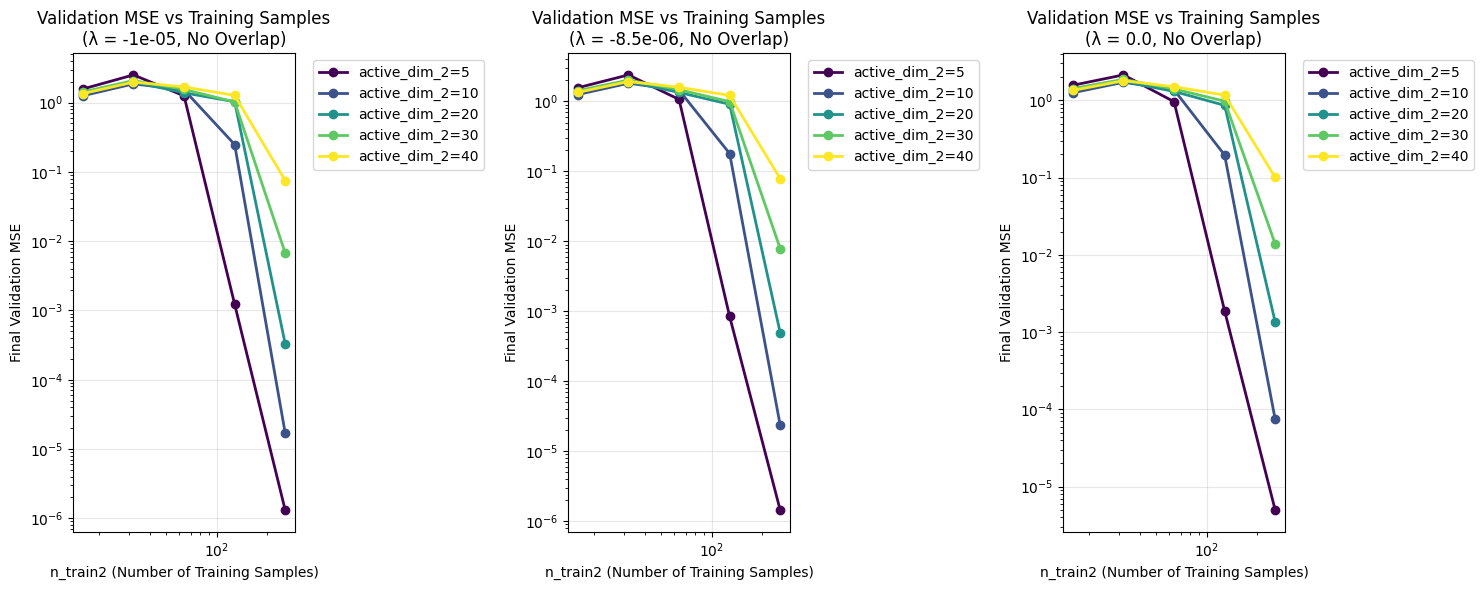

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
df = pd.read_csv('/home/na658/multi-task2/experiment_results_no_overlap.csv')

# Filter for the relevant experiments (one_task=True, overlap_bool='no')
df_filtered = df[
    (df['one_task'] == True) & 
    (df['overlap_bool'] == 'no')
].copy()

# Get unique lmda values and sort them
lmda_values = sorted(df_filtered['lmda'].unique())
print(f"Found {len(lmda_values)} unique lmda values: {lmda_values}")

# Create a subplot for each lmda value
fig, axes = plt.subplots(1, len(lmda_values), figsize=(5*len(lmda_values), 6))
if len(lmda_values) == 1:
    axes = [axes]  # Make it iterable for single subplot

for lmda_idx, lmda_val in enumerate(lmda_values):
    ax = axes[lmda_idx]
    
    # Filter data for this lmda value
    df_lmda = df_filtered[df_filtered['lmda'] == lmda_val].copy()
    
    # Get unique active_dim_2 values and sort them
    active_dims = sorted(df_lmda['active_dim_2'].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(active_dims)))
    
    # Plot Final Validation MSE vs n_train2 for different active_dim_2
    for i, active_dim in enumerate(active_dims):
        subset = df_lmda[df_lmda['active_dim_2'] == active_dim]
        ax.plot(subset['n_train2'], subset['final_val_mse'], 
                'o-', color=colors[i], label=f'active_dim_2={active_dim}', 
                linewidth=2, markersize=6)
    
    ax.set_xlabel('n_train2 (Number of Training Samples)')
    ax.set_ylabel('Final Validation MSE')
    ax.set_title(f'Validation MSE vs Training Samples\n(λ = {lmda_val}, No Overlap)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Found 3 unique lmda values: [np.float64(-1e-05), np.float64(-8.5e-06), np.float64(0.0)]


/tmp/ipykernel_1275447/2344367102.py:36: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(subset['n_train2'], subset['final_val_mse'],


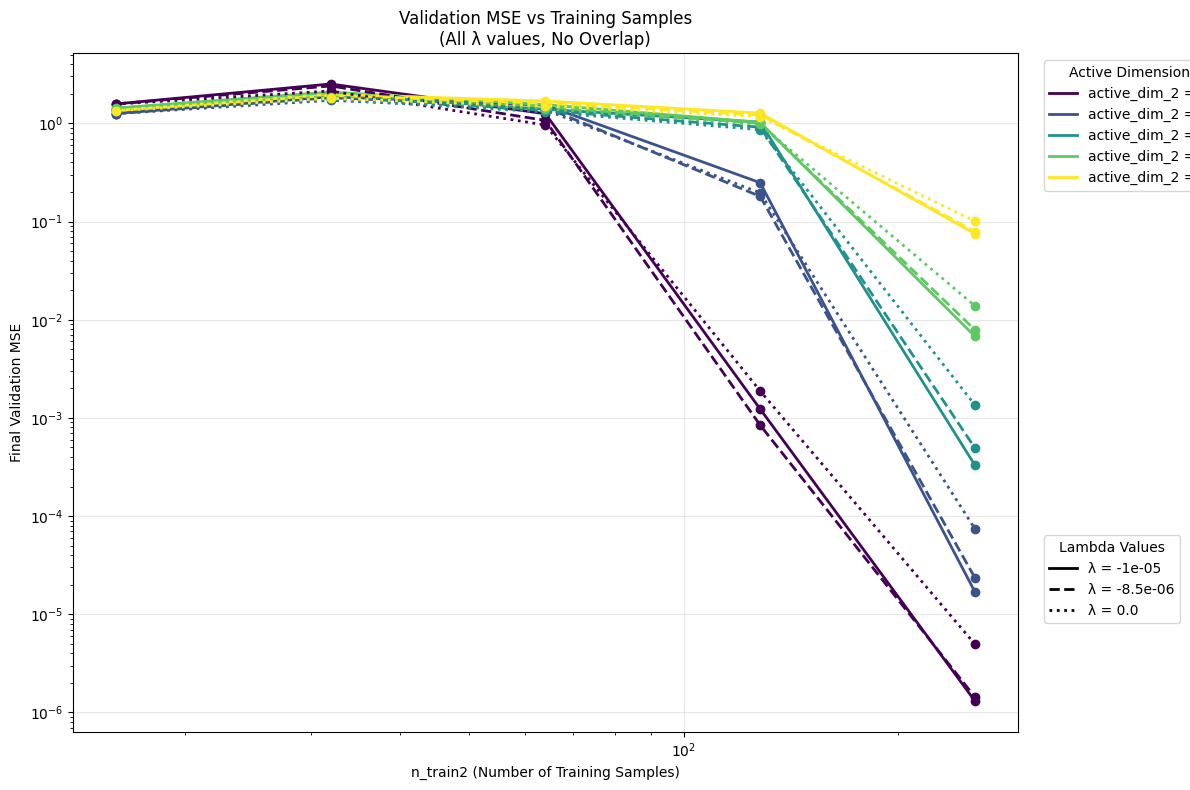

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
df = pd.read_csv('/home/na658/multi-task2/experiment_results_no_overlap.csv')

# Filter for the relevant experiments (one_task=True, overlap_bool='no')
df_filtered = df[
    (df['one_task'] == True) & 
    (df['overlap_bool'] == 'no')
].copy()

# Get unique lmda values and sort them
lmda_values = sorted(df_filtered['lmda'].unique())
print(f"Found {len(lmda_values)} unique lmda values: {lmda_values}")

# Define line styles for different lmda values
line_styles = ['-', '--', ':']  # solid, dashed, dotted

# Create the plot
plt.figure(figsize=(12, 8))

# Get unique active_dim_2 values and sort them
active_dims = sorted(df_filtered['active_dim_2'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(active_dims)))

# Plot for each lmda value
for lmda_idx, lmda_val in enumerate(lmda_values):
    df_lmda = df_filtered[df_filtered['lmda'] == lmda_val].copy()
    
    # Plot for each active_dim_2
    for i, active_dim in enumerate(active_dims):
        subset = df_lmda[df_lmda['active_dim_2'] == active_dim]
        if not subset.empty:
            plt.plot(subset['n_train2'], subset['final_val_mse'], 
                    'o-', color=colors[i], linestyle=line_styles[lmda_idx % len(line_styles)],
                    linewidth=2, markersize=6)

# Create first legend for active_dim_2 (colors)
legend_elements_1 = []
for i, active_dim in enumerate(active_dims):
    legend_elements_1.append(plt.Line2D([0], [0], color=colors[i], lw=2, 
                                       label=f'active_dim_2 = {active_dim}'))

legend1 = plt.legend(handles=legend_elements_1, title='Active Dimensions', 
                    bbox_to_anchor=(1.02, 1), loc='upper left')

# Create second legend for lmda values (line styles)
legend_elements_2 = []
for lmda_idx, lmda_val in enumerate(lmda_values):
    legend_elements_2.append(plt.Line2D([0], [0], color='black', 
                                       linestyle=line_styles[lmda_idx % len(line_styles)],
                                       lw=2, label=f'λ = {lmda_val}'))

legend2 = plt.legend(handles=legend_elements_2, title='Lambda Values', 
                    bbox_to_anchor=(1.02, 0.3), loc='upper left')

# Add the first legend back to the plot
plt.gca().add_artist(legend1)

plt.xlabel('n_train2 (Number of Training Samples)')
plt.ylabel('Final Validation MSE')
plt.title('Validation MSE vs Training Samples\n(All λ values, No Overlap)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
df = pd.read_csv('/home/na658/multi-task2/experiment_results.csv')

In [17]:
df.pretrain_overlap.value_counts()

pretrain_overlap
5.0     15
20.0    15
30.0    12
40.0    12
Name: count, dtype: int64

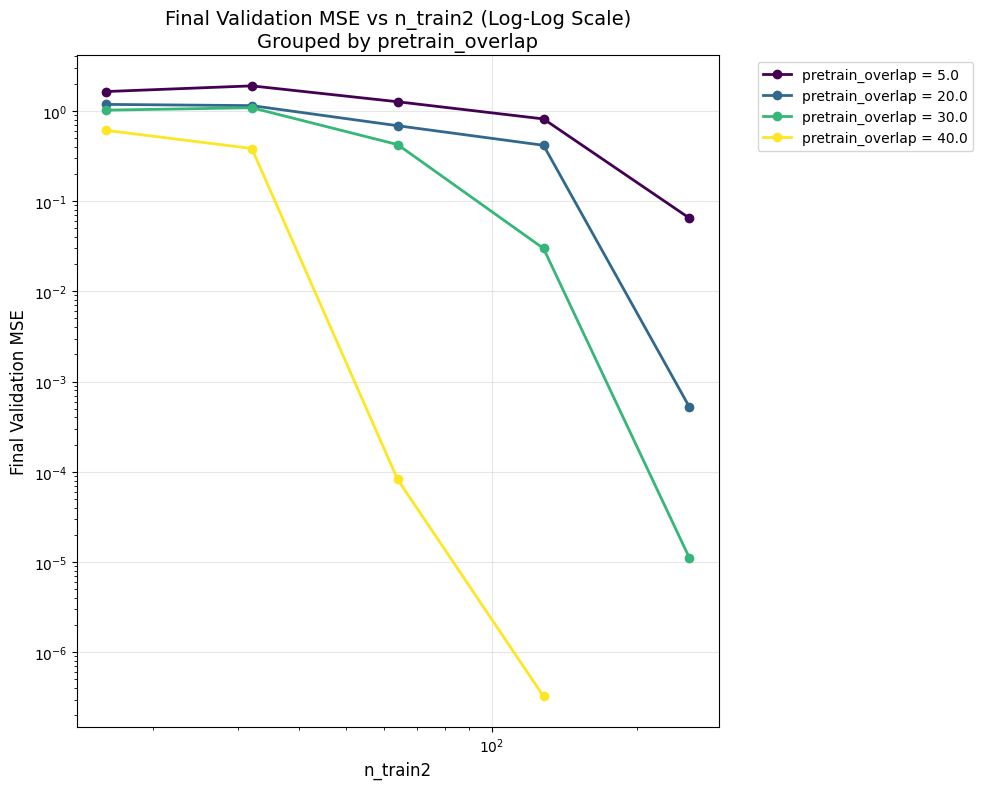

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv('/home/na658/multi-task2/experiment_results.csv')

# Create the plot
plt.figure(figsize=(10, 8))

# Get unique pretrain_overlap values and sort them
overlap_values = sorted(df['pretrain_overlap'].unique())

# Define colors for different curves
colors = plt.cm.viridis(np.linspace(0, 1, len(overlap_values)))

# Plot each curve for different pretrain_overlap values
for i, overlap in enumerate(overlap_values):
    # Filter data for this overlap value
    subset = df[df['pretrain_overlap'] == overlap]
    
    # Group by n_train2 and calculate mean final_val_mse (in case there are multiple runs)
    grouped = subset.groupby('n_train2')['final_val_mse'].mean().reset_index()
    
    # Create log-log plot
    plt.loglog(grouped['n_train2'], grouped['final_val_mse'], 
               'o-', color=colors[i], linewidth=2, markersize=6,
               label=f'pretrain_overlap = {overlap}')

# Customize the plot
plt.xlabel('n_train2', fontsize=12)
plt.ylabel('Final Validation MSE', fontsize=12)
plt.title('Final Validation MSE vs n_train2 (Log-Log Scale)\nGrouped by pretrain_overlap', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

/tmp/ipykernel_1275447/3958802508.py:38: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.loglog(grouped['n_train2'], grouped['final_val_mse'],
/tmp/ipykernel_1275447/3958802508.py:38: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.loglog(grouped['n_train2'], grouped['final_val_mse'],
/tmp/ipykernel_1275447/3958802508.py:38: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.loglog(grouped['n_train2'], grouped['final_val_mse'],
/tmp/ipykernel_1275447/3958802508.py:38: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument wi

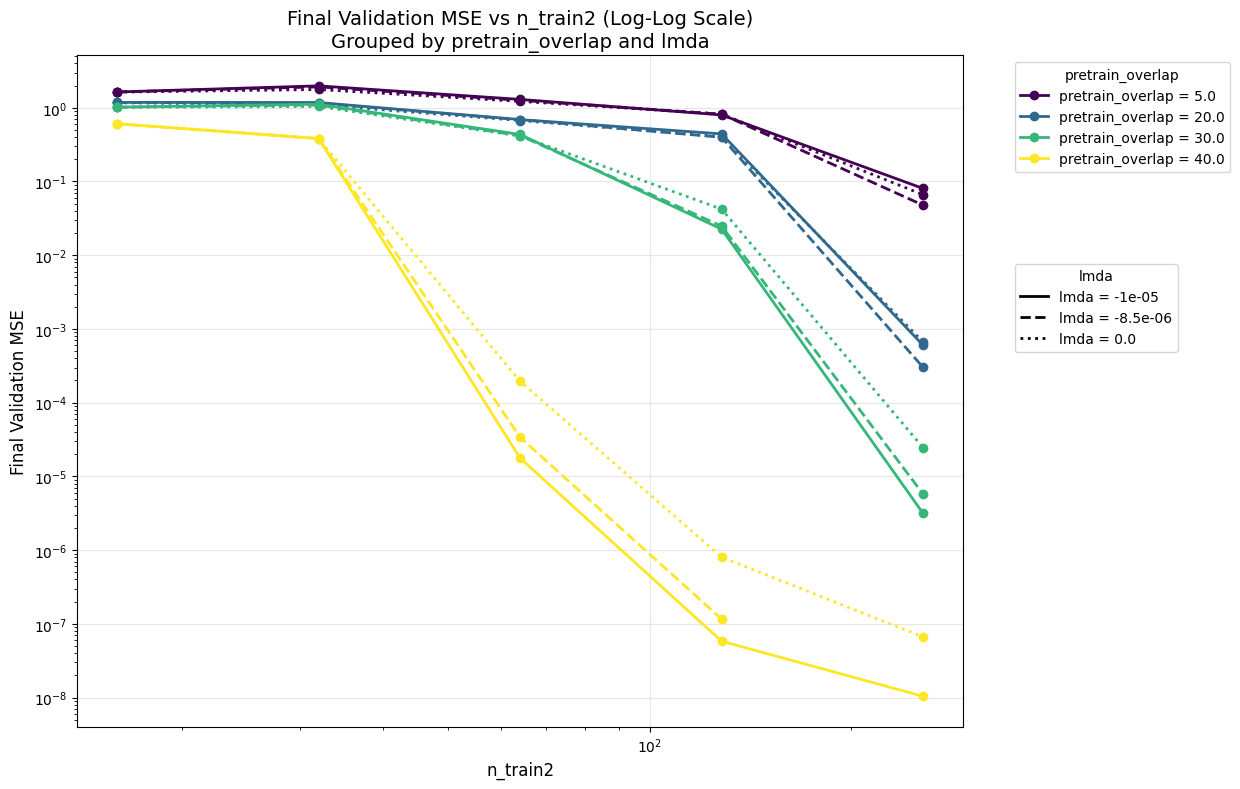

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv('/home/na658/multi-task2/experiment_results.csv')

# Create the plot
plt.figure(figsize=(12, 8))

# Get unique values and sort them
overlap_values = sorted(df['pretrain_overlap'].unique())
lmda_values = sorted(df['lmda'].unique())

# Define colors for different pretrain_overlap values
colors = plt.cm.viridis(np.linspace(0, 1, len(overlap_values)))

# Define line styles for different lmda values
line_styles = ['-', '--', ':']  # solid, dashed, dotted

# Plot each curve for different combinations
for i, overlap in enumerate(overlap_values):
    for j, lmda in enumerate(lmda_values):
        # Filter data for this combination
        subset = df[(df['pretrain_overlap'] == overlap) & (df['lmda'] == lmda)]
        
        if len(subset) > 0:  # Only plot if data exists
            # Group by n_train2 and calculate mean final_val_mse
            grouped = subset.groupby('n_train2')['final_val_mse'].mean().reset_index()
            
            # Create label for this combination
            if j == 0:  # Only add overlap to label for first lmda value to avoid repetition
                label = f'pretrain_overlap = {overlap}'
            else:
                label = None
            
            # Create log-log plot
            plt.loglog(grouped['n_train2'], grouped['final_val_mse'], 
                       'o-', color=colors[i], linewidth=2, markersize=6,
                       linestyle=line_styles[j], label=label)

# Create custom legend for lmda values
from matplotlib.lines import Line2D
lmda_legend_elements = [Line2D([0], [0], color='black', linestyle=line_styles[j], 
                              linewidth=2, label=f'lmda = {lmda}') 
                       for j, lmda in enumerate(lmda_values)]

# Customize the plot
plt.xlabel('n_train2', fontsize=12)
plt.ylabel('Final Validation MSE', fontsize=12)
plt.title('Final Validation MSE vs n_train2 (Log-Log Scale)\nGrouped by pretrain_overlap and lmda', fontsize=14)

# Add legends
legend1 = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='pretrain_overlap')
legend2 = plt.legend(handles=lmda_legend_elements, bbox_to_anchor=(1.05, 0.7), loc='upper left', title='lmda')
plt.gca().add_artist(legend1)  # Add the first legend back

plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

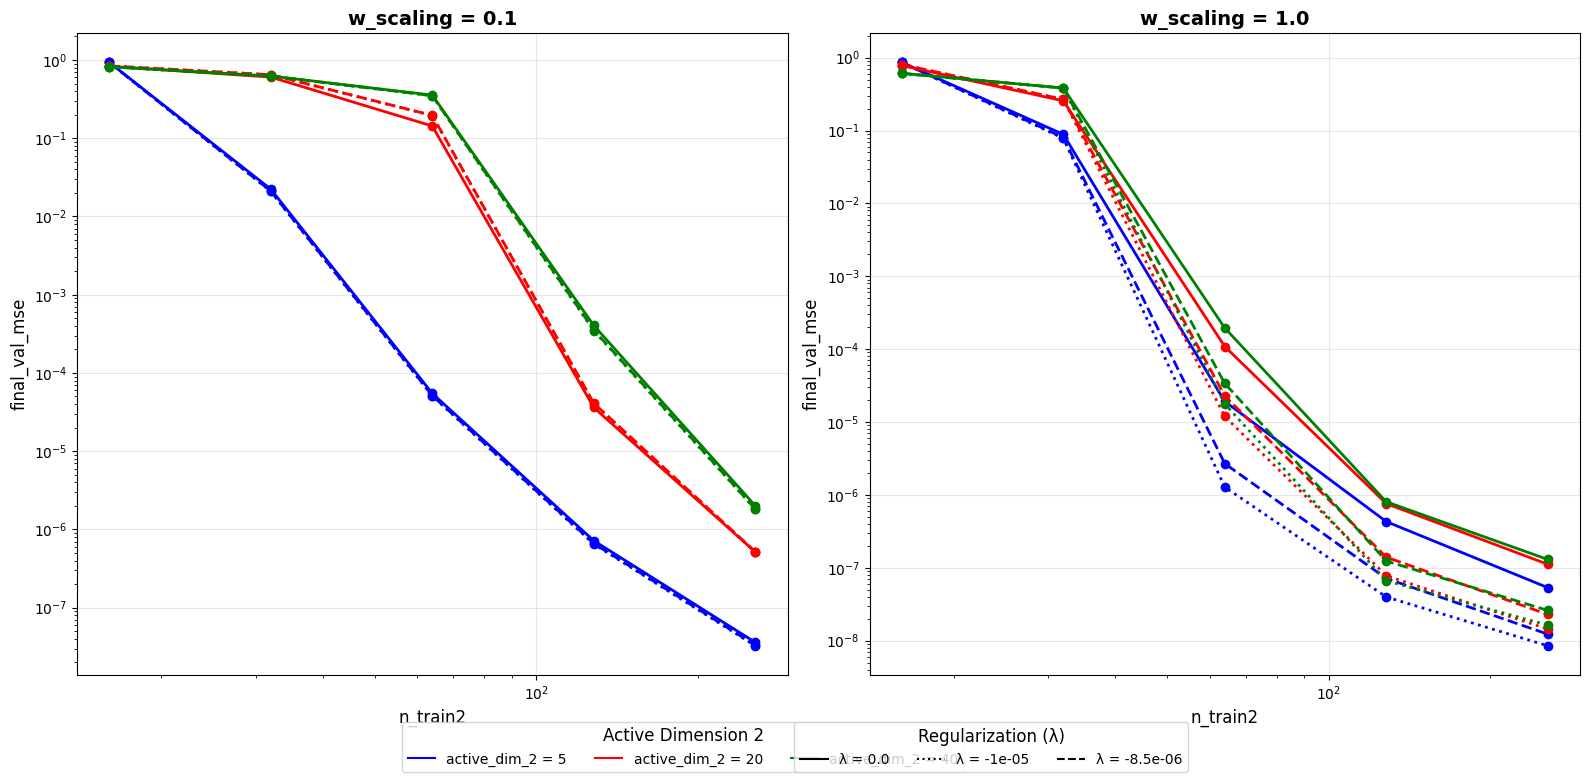

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
df = pd.read_csv('/home/na658/multi-task2/experiment_results.csv')

# Create the plots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Define colors for active_dim_2
colors = {5: 'blue', 20: 'red', 40: 'green'}

# Define line styles for lmda
line_styles = {
    0.0: '-',           # solid
    -1e-05: ':',        # dotted
    -8.5e-06: '--'      # dashed
}

# Plot for each w_scaling value
for idx, w_scaling in enumerate([0.1, 1.0]):
    ax = axes[idx]
    
    # Filter data for current w_scaling
    data_subset = df[df['w_scaling'] == w_scaling]
    
    # Plot lines for each combination of active_dim_2 and lmda
    for active_dim_2 in sorted(data_subset['active_dim_2'].unique()):
        for lmda in sorted(data_subset['lmda'].unique()):
            # Filter data for this combination
            mask = (data_subset['active_dim_2'] == active_dim_2) & (data_subset['lmda'] == lmda)
            subset = data_subset[mask].sort_values('n_train2')
            
            if len(subset) > 0:
                # Create label
                label = f'active_dim_2={active_dim_2}, λ={lmda}'
                
                # Plot with log-log scale
                ax.loglog(subset['n_train2'], subset['final_val_mse'], 
                         color=colors[active_dim_2], 
                         linestyle=line_styles[lmda],
                         marker='o', 
                         label=label,
                         linewidth=2)
    
    # Customize the subplot
    ax.set_xlabel('n_train2', fontsize=12)
    ax.set_ylabel('final_val_mse', fontsize=12)
    ax.set_title(f'w_scaling = {w_scaling}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Set log scale for both axes
    ax.set_xscale('log')
    ax.set_yscale('log')

# Create two separate legends at the bottom
# Legend 1: Colors for active_dim_2
legend1_elements = [
    plt.Line2D([0], [0], color='blue', linestyle='-', label='active_dim_2 = 5'),
    plt.Line2D([0], [0], color='red', linestyle='-', label='active_dim_2 = 20'),
    plt.Line2D([0], [0], color='green', linestyle='-', label='active_dim_2 = 40')
]

# Legend 2: Line styles for lmda
legend2_elements = [
    plt.Line2D([0], [0], color='black', linestyle='-', label='λ = 0.0'),
    plt.Line2D([0], [0], color='black', linestyle=':', label='λ = -1e-05'),
    plt.Line2D([0], [0], color='black', linestyle='--', label='λ = -8.5e-06')
]

# Add legends at the bottom of the figure
legend1 = fig.legend(handles=legend1_elements, loc='lower left', bbox_to_anchor=(0.25, 0.02), 
                    title='Active Dimension 2', fontsize=10, title_fontsize=12, ncol=3)
legend2 = fig.legend(handles=legend2_elements, loc='lower right', bbox_to_anchor=(0.75, 0.02), 
                    title='Regularization (λ)', fontsize=10, title_fontsize=12, ncol=3)

# Adjust layout to make room for legends at the bottom
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Make room for legends at the bottom
plt.show()